In [2]:
!nvidia-smi

Wed Jun 25 13:13:27 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.62                 Driver Version: 572.62         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   40C    P8              1W /  115W |       7MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install PyMuPDF
!pip install python-Levenshtein
!pip install editdistance

In [4]:
!pip install scikit-image

   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.9 MB 3.7 MB/s eta 0:00:04
   ---- ----------------------------------- 1.6/12.9 MB 3.4 MB/s eta 0:00:04
   ------ --------------------------------- 2.1/12.9 MB 3.3 MB/s eta 0:00:04
   -------- ------------------------------- 2.6/12.9 MB 3.2 MB/s eta 0:00:04
   ---------- ----------------------------- 3.4/12.9 MB 3.1 MB/s eta 0:00:04
   ------------ --------------------------- 3.9/12.9 MB 3.1 MB/s eta 0:00:03
   -------------- ------------------------- 4.7/12.9 MB 3.1 MB/s eta 0:00:03
   ---------------- ----------------------- 5.2/12.9 MB 3.1 MB/s eta 0:00:03
   ----------------- ---------------------- 5.8/12.9 MB 3.1 MB/s eta 0:00:03
   -------------------- ------------------- 6.6/12.9 MB 3.1 MB/s eta 0:00:03
   --------------------- ------------------ 7.1/12.9 MB 3.1 MB/s eta 0:00:02
   ------------------------ --------------- 7.9/12.9 MB 3.1 MB/s eta 0:00:02
   ---

In [14]:
!pip install python-docx

In [15]:
# Restart the notebook
!pip install transformers[torch]
!pip install accelerate -U

  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.4.0
    Uninstalling accelerate-1.4.0:
      Successfully uninstalled accelerate-1.4.0


In [16]:
# Restart the notebook
!pip install evaluate
!pip install jiwer

# Installing Transformer Model


In [3]:
!pip install -q git+https://github.com/huggingface/transformers.git


In [13]:
import os
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt
from heapq import heappop, heappush
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch
from torch.utils.data import Dataset, DataLoader

In [14]:
import shutil
import os


file_path1 = 'A/Padilla - 1 Nobleza virtuosa_Extract.pdf'
doc_path1 = 'A/Padilla - 1 Nobleza virtuosa_Transcription (1).docx'
file_path2 = 'A/Padilla - 2 Noble perfecto_Extract.pdf'
doc_path2 = 'A/Padilla - 2 Noble perfecto_Transcription.docx'

# extended dataset A

doc_path1 = 'A/Dataset A/PORCONES.228.35 – 1636 transcription.docx'
doc_path2 = 'A/Dataset A/PORCONES.82.4 – 1644 transcription.docx'
doc_path3 = 'A/Dataset A/PORCONES.954.2.45 transcription.docx'

# extended dataset B
dp1 = 'A/Dataset B - different typeface/Buendia transcription.docx'
dp2 = 'A/Dataset B - different typeface/Constituciones sinodales transcription.docx'
dp3 = 'A/Dataset B - different typeface/Covarrubias transcription.docx'
dp4 = 'A/Dataset B - different typeface/Ezcaray transcription.docx'
dp5 = 'A/Dataset B - different typeface/Guardiola transcription.docx'
dp6 = 'A/Dataset B - different typeface/Mendo transcription.docx'
dp7 = 'A/Dataset B - different typeface/Milán transcription.docx'
dp8 = 'A/Dataset B - different typeface/Paredes transcription.docx'
dp9 = 'A/Dataset B - different typeface/R.12175.3 transcription.docx'
dp10 = 'A/Dataset B - different typeface/Recopilacion transcription.docx'

# Converting PDF To Png

In [15]:
import fitz
from PIL import Image
import os

def convert_pdf_to_images(pdf_path, output_folder,book):
    doc = fitz.open(pdf_path)
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    image_paths = []
    for page_num in range(16):
        page = doc.load_page(page_num)
        pix = page.get_pixmap()
        image_path = os.path.join(output_folder, f"{book}_page_{page_num + 1}.png")
        image_path = image_path.replace('\\', '/')
        pix.save(image_path)
        image_paths.append(image_path)

    doc.close()
    return image_paths


In [16]:
pdf_path1 = "A/Padilla - 1 Nobleza virtuosa_Extract.pdf"
image_folder1 = "/content/image_folder1"
book1 = 'Padilla - 1'
pdf_path2 = "A/Padilla - 2 Noble perfecto_Extract.pdf"
image_folder2 = "/content/image_folder2"
book2 = 'Padilla - 2'
image_path1 = convert_pdf_to_images(pdf_path1, image_folder1,book1)
image_path2 = convert_pdf_to_images(pdf_path2, image_folder2,book2)

image_path = []
image_path.extend(image_path1)
image_path.extend(image_path2)
print(image_path)

['/content/image_folder1/Padilla - 1_page_1.png', '/content/image_folder1/Padilla - 1_page_2.png', '/content/image_folder1/Padilla - 1_page_3.png', '/content/image_folder1/Padilla - 1_page_4.png', '/content/image_folder1/Padilla - 1_page_5.png', '/content/image_folder1/Padilla - 1_page_6.png', '/content/image_folder1/Padilla - 1_page_7.png', '/content/image_folder1/Padilla - 1_page_8.png', '/content/image_folder1/Padilla - 1_page_9.png', '/content/image_folder1/Padilla - 1_page_10.png', '/content/image_folder1/Padilla - 1_page_11.png', '/content/image_folder1/Padilla - 1_page_12.png', '/content/image_folder1/Padilla - 1_page_13.png', '/content/image_folder1/Padilla - 1_page_14.png', '/content/image_folder1/Padilla - 1_page_15.png', '/content/image_folder1/Padilla - 1_page_16.png', '/content/image_folder2/Padilla - 2_page_1.png', '/content/image_folder2/Padilla - 2_page_2.png', '/content/image_folder2/Padilla - 2_page_3.png', '/content/image_folder2/Padilla - 2_page_4.png', '/content/im

In [17]:
# Dataset A
image_path3 = ['/content/image_folder3/PORCONES.82.4 – 1644_page_1.png','/content/image_folder3/PORCONES.82.4 – 1644_page_2.png','/content/image_folder3/PORCONES.82.4 – 1644_page_3.png']
image_path4 = ['/content/image_folder4/PORCONES.954.2.45_page_1.png','/content/image_folder3/PORCONES.954.2.45_page_2.png']
image_path5 = ['/content/image_folder5/PORCONES.228.35 – 1636_page_1.png','/content/image_folder5/PORCONES.228.35 – 1636_page_2.png','/content/image_folder5/PORCONES.228.35 – 1636_page_3.png']

# Dataset B
image_path6 = ['/content/image_folder6/Buendia - Instruccion_page_2.png','/content/image_folder6/Buendia - Instruccion_page_3.png','/content/image_folder6/Buendia - Instruccion_page_4.png']
image_path7 = ['/content/image_folder7/Constituciones sinodales Calahorra 1602_page_2.png','/content/image_folder7/Constituciones sinodales Calahorra 1602_page_3.png','/content/image_folder7/Constituciones sinodales Calahorra 1602_page_4.png']
image_path8 = ['/content/image_folder8/Covarrubias - Tesoro lengua_page_7.png','/content/image_folder8/Covarrubias - Tesoro lengua_page_8.png','/content/image_folder8/Covarrubias - Tesoro lengua_page_9.png']
image_path9 = ['/content/image_folder9/Ezcaray - Vozes_page_8.png','/content/image_folder9/Ezcaray - Vozes_page_9.png','/content/image_folder9/Ezcaray - Vozes_page_10.png']
image_path10 = ['/content/image_folder10/Guardiola - Tratado nobleza_page_12.png','/content/image_folder10/Guardiola - Tratado nobleza_page_13.png','/content/image_folder10/Guardiola - Tratado nobleza_page_14.png']
image_path11 = ['/content/image_folder11/Mendo - Principe perfecto_page_14.png','/content/image_folder11/Mendo - Principe perfecto_page_15.png','/content/image_folder11/Mendo - Principe perfecto_page_16.png','/content/image_folder11/Mendo - Principe perfecto_page_17.png','/content/image_folder11/Mendo - Principe perfecto_page_18.png']
image_path12 = ['/content/image_folder12/Milán - El cortesano_page_6.png','/content/image_folder12/Milán - El cortesano_page_7.png']
image_path13 = ['/content/image_folder13/Paredes - Reglas generales_page_18.png','/content/image_folder13/Paredes - Reglas generales_page_19.png']
image_path14 = ['/content/image_folder14/R.12175.3 - Zamora_page_5.png','/content/image_folder14/R.12175.3 - Zamora_page_6.png']
image_path15 = ['/content/image_folder15/Recopilacion leyes 1640_page_11.png','/content/image_folder15/Recopilacion leyes 1640_page_12.png','/content/image_folder15/Recopilacion leyes 1640_page_13.png']


image_path.extend(image_path3)
image_path.extend(image_path4)
image_path.extend(image_path5)
image_path.extend(image_path6)
image_path.extend(image_path7)
image_path.extend(image_path8)
image_path.extend(image_path9)
image_path.extend(image_path10)
image_path.extend(image_path11)
image_path.extend(image_path12)
image_path.extend(image_path13)
image_path.extend(image_path14)
image_path.extend(image_path15)
print(image_path)

['/content/image_folder1/Padilla - 1_page_1.png', '/content/image_folder1/Padilla - 1_page_2.png', '/content/image_folder1/Padilla - 1_page_3.png', '/content/image_folder1/Padilla - 1_page_4.png', '/content/image_folder1/Padilla - 1_page_5.png', '/content/image_folder1/Padilla - 1_page_6.png', '/content/image_folder1/Padilla - 1_page_7.png', '/content/image_folder1/Padilla - 1_page_8.png', '/content/image_folder1/Padilla - 1_page_9.png', '/content/image_folder1/Padilla - 1_page_10.png', '/content/image_folder1/Padilla - 1_page_11.png', '/content/image_folder1/Padilla - 1_page_12.png', '/content/image_folder1/Padilla - 1_page_13.png', '/content/image_folder1/Padilla - 1_page_14.png', '/content/image_folder1/Padilla - 1_page_15.png', '/content/image_folder1/Padilla - 1_page_16.png', '/content/image_folder2/Padilla - 2_page_1.png', '/content/image_folder2/Padilla - 2_page_2.png', '/content/image_folder2/Padilla - 2_page_3.png', '/content/image_folder2/Padilla - 2_page_4.png', '/content/im

# Extract the text from doc and assign it to its corresponding image(page)

In [18]:
import docx

# Step2
transcript = {}
def read_transcriptions(image_paths, file_path):
    # Load the DOCX file
    doc = docx.Document(file_path)

    # Initialize the dictionary to store text from each page

    # Extract text from each paragraph and assign it to the corresponding image path in the dictionary
    text = ''
    image_index = -1
    num_images = len(image_paths)

    for para in doc.paragraphs:
        stripped_text = para.text.strip()
        if "PDF" in stripped_text or "END OF EXTRACT" in stripped_text:
            if image_index >= 0:
                transcript[image_paths[image_index]] = text.strip()
            image_index += 1
            text = ''
        elif stripped_text != '':
            text += stripped_text + "\n"

    # Add the last page text if exists
    if text.strip() and image_index < num_images:
        transcript[image_paths[image_index]] = text.strip()

    return transcript


In [19]:
transcription_path = "A/Padilla - 1 Nobleza virtuosa_Transcription (1).docx"
transcriptions = read_transcriptions(image_path1, transcription_path)  # Read transcriptions
transcription_path = "A/Padilla - 2 Noble perfecto_Transcription.docx"
transcriptions = read_transcriptions(image_path2, transcription_path)

# Dataset A
transcription_path = "A/Dataset A/PORCONES.82.4 – 1644 transcription.docx"
transcriptions = read_transcriptions(image_path3, transcription_path)
transcription_path = "A/Dataset A/PORCONES.954.2.45 transcription.docx"
transcriptions = read_transcriptions(image_path4, transcription_path)
transcription_path = "A/Dataset A/PORCONES.228.35 – 1636 transcription.docx"
transcriptions = read_transcriptions(image_path5, transcription_path)

# Dataset B

transcription_path = "A/Dataset B - different typeface/Buendia transcription.docx"
transcriptions = read_transcriptions(image_path6, transcription_path)
transcription_path = "A/Dataset B - different typeface/Constituciones sinodales transcription.docx"
transcriptions = read_transcriptions(image_path7, transcription_path)
transcription_path = "A/Dataset B - different typeface/Covarrubias transcription.docx"
transcriptions = read_transcriptions(image_path8, transcription_path)
transcription_path = "A/Dataset B - different typeface/Ezcaray transcription.docx"
transcriptions = read_transcriptions(image_path9, transcription_path)
transcription_path = "A/Dataset B - different typeface/Guardiola transcription.docx"
transcriptions = read_transcriptions(image_path10, transcription_path)
transcription_path = "A/Dataset B - different typeface/Mendo transcription.docx"
transcriptions = read_transcriptions(image_path11, transcription_path)
transcription_path = "A/Dataset B - different typeface/Milán transcription.docx"
transcriptions = read_transcriptions(image_path12, transcription_path)
transcription_path = "A/Dataset B - different typeface/Paredes transcription.docx"
transcriptions = read_transcriptions(image_path13, transcription_path)
transcription_path = "A/Dataset B - different typeface/R.12175.3 transcription.docx"
transcriptions = read_transcriptions(image_path14, transcription_path)
transcription_path = "A/Dataset B - different typeface/Recopilacion transcription.docx"
transcriptions = read_transcriptions(image_path15, transcription_path)


print(transcript.keys())

dict_keys(['/content/image_folder1/Padilla - 1_page_1.png', '/content/image_folder1/Padilla - 1_page_2.png', '/content/image_folder1/Padilla - 1_page_3.png', '/content/image_folder1/Padilla - 1_page_4.png', '/content/image_folder1/Padilla - 1_page_5.png', '/content/image_folder1/Padilla - 1_page_6.png', '/content/image_folder1/Padilla - 1_page_7.png', '/content/image_folder1/Padilla - 1_page_8.png', '/content/image_folder1/Padilla - 1_page_9.png', '/content/image_folder1/Padilla - 1_page_10.png', '/content/image_folder1/Padilla - 1_page_11.png', '/content/image_folder1/Padilla - 1_page_12.png', '/content/image_folder1/Padilla - 1_page_13.png', '/content/image_folder1/Padilla - 1_page_14.png', '/content/image_folder1/Padilla - 1_page_15.png', '/content/image_folder1/Padilla - 1_page_16.png', '/content/image_folder2/Padilla - 2_page_1.png', '/content/image_folder2/Padilla - 2_page_2.png', '/content/image_folder2/Padilla - 2_page_3.png', '/content/image_folder2/Padilla - 2_page_4.png', '/

# Aligning Line segemented images with its corresponding text

In [9]:
# Without augmentations

import os
import re
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray

def get_segmented_image_paths(input_path, segmented_image_dir):
    # Get the base name from the input path
    base_name = os.path.basename(input_path)
    # print(base_name)
    # List all files in the directory
    files = os.listdir(segmented_image_dir)

    # Filter the files to get only those that start with the base name and end with "_line_*.png"
    segmented_files = [os.path.join(segmented_image_dir, f) for f in files if f.startswith(base_name) and "_line_" in f and f.endswith(".png")]

    return segmented_files

def extract_line_number(file_path):
    # Extract the line number(s) from the file name using regex
    match = re.search(r'_line_(\d+(_\d+)?).png$', file_path)
    if match:
        return list(map(int, match.group(1).split('_')))
    return [-1]

def sort_segmented_image_paths(image_paths):
    # Sort the list of paths based on the extracted line number
    sorted_paths = sorted(image_paths, key=extract_line_number)
    return sorted_paths

def align_segments_with_transcriptions(image_path, line_segmentation_path, transcription):
    segmented_image_paths = get_segmented_image_paths(image_path, line_segmentation_path)
    segmented_image_paths = sort_segmented_image_paths(segmented_image_paths)
    line_text = transcription.split('\n')

    count = 0
    data = []

    for path in segmented_image_paths:
        transcript = ""

        line_img = imread(path)[:,:,:3]

        if line_img.ndim > 2:
            line_img = rgb2gray(line_img)
        try:
            transcript = line_text[count]
            count += 1
            data.append((line_img, transcript))
            # print(count)
        except Exception as e:
            print(f"Error processing {image_path} - {path}: {e}")
            print(len(segmented_image_paths),len(line_text))
            print('\n')
            continue
    return data

# segmented_image_folder = "/content/drive/MyDrive/A/Line_Segmented_images"
segmented_image_folder = "A/New_Line_Segmented_images"
aligned_data = {}


for img_path in image_path:
    if img_path == '/content/image_folder8/Covarrubias - Tesoro lengua_page_8.png' or img_path == '/content/image_folder8/Covarrubias - Tesoro lengua_page_9.png':
        continue
    aligned_data[img_path] = align_segments_with_transcriptions(img_path, segmented_image_folder, transcript[img_path])


In [10]:
total_line_segments = sum(len(data) for data in aligned_data.values())
print(f"Total line segment images: {total_line_segments}")

Total line segment images: 2693


In [9]:
# with augmentations
import os
import re
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
import albumentations as A

def get_segmented_image_paths(input_path, segmented_image_dir):
    base_name = os.path.basename(input_path)
    files = os.listdir(segmented_image_dir)
    segmented_files = [os.path.join(segmented_image_dir, f) for f in files if f.startswith(base_name) and "_line_" in f and f.endswith(".png")]
    return segmented_files

def extract_line_number(file_path):
    match = re.search(r'_line_(\d+(_\d+)?).png$', file_path)
    if match:
        return list(map(int, match.group(1).split('_')))
    return [-1]

def sort_segmented_image_paths(image_paths):
    sorted_paths = sorted(image_paths, key=extract_line_number)
    return sorted_paths

def apply_augmentations(image):
    augmentations = [
        A.Rotate(limit=3, p=1.0),
        A.ElasticTransform(alpha=0.3, sigma=100.0, p=1.0),
        A.OpticalDistortion(distort_limit=0.03, p=1.0),
        A.CLAHE(clip_limit=2, tile_grid_size=(4, 4), p=1.0),
        A.Affine(scale=(0.95, 1.05), translate_percent=(0.02, 0.02), shear=(-2, 2), p=1.0),
        A.Perspective(scale=(0.01, 0.03), p=1.0),
        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=1.0),
        A.GaussianBlur(blur_limit=(3, 7), p=1.0),
        A.GridDistortion(num_steps=3, distort_limit=0.02, p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ]

    # Ensure the image is in np.uint8 format to avoid type mismatch
    image = image.astype(np.uint8)

    augmented_images = []
    for transform in augmentations:
        augmented_images.append(transform(image=image)['image'])
    
    return augmented_images


def align_segments_with_transcriptions(image_path, line_segmentation_path, transcription):

    segmented_image_paths = get_segmented_image_paths(image_path, line_segmentation_path)
    segmented_image_paths = sort_segmented_image_paths(segmented_image_paths)
    line_text = transcription.split('\n')

    count = 0
    data = []

    for path in segmented_image_paths:
        transcript = ""

        line_img = imread(path)[:,:,:3]

        if line_img.ndim > 2:
            line_img = rgb2gray(line_img)

        try:
            height = line_img.shape[0]
            transcript = line_text[count]
            count += 1

            # Apply augmentations and store results
            augmented_images = apply_augmentations(line_img)
            for aug_img in augmented_images:
                data.append((aug_img, transcript))

            # Store the original image and transcript
            data.append((line_img, transcript))
        except Exception as e:
            print(f"Error processing {image_path} - {path}: {e}")
            continue
    return data

segmented_image_folder = "A/New_Line_Segmented_images"
aligned_data = {}

for img_path in image_path:
    if img_path == '/content/image_folder8/Covarrubias - Tesoro lengua_page_8.png' or img_path == '/content/image_folder8/Covarrubias - Tesoro lengua_page_9.png':
        continue
    aligned_data[img_path] = align_segments_with_transcriptions(img_path, segmented_image_folder, transcript[img_path])


In [10]:
total_line_segments = sum(len(data) for data in aligned_data.values())
print(f"Total line segment images: {total_line_segments}")

Total line segment images: 29623


# Training 11

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, Trainer, TrainingArguments, EarlyStoppingCallback
from PIL import Image
import numpy as np
from torch.nn.utils.rnn import pad_sequence
from torch.optim import AdamW
import torch.nn.functional as F
from evaluate import load
import albumentations as A
from transformers import get_cosine_schedule_with_warmup
import os

# Enable mixed precision training
torch.backends.cudnn.benchmark = True
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'


# Load metrics
cer_metric = load("cer")
wer_metric = load("wer")

# model_path = "qantev/trocr-large-spanish"
# processor_path = "qantev/trocr-large-spanish"

model_path = "./finetuned_transformer_model_v4"
processor_path = "./finetuned_transformer_model_v4"

processor = TrOCRProcessor.from_pretrained(processor_path, do_rescale=False,use_fast=True)
model = VisionEncoderDecoderModel.from_pretrained(model_path)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    predictions = logits.argmax(-1)
    decoded_preds = processor.tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = []
    for label in labels:
        label_filtered = [token for token in label if token != -100]
        decoded_label = processor.tokenizer.decode(label_filtered, skip_special_tokens=True)
        decoded_labels.append(decoded_label)
    cer_score = cer_metric.compute(predictions=decoded_preds, references=decoded_labels)
    wer_score = wer_metric.compute(predictions=decoded_preds, references=decoded_labels)
    return {"cer": cer_score, "wer": wer_score}

class LineDataset(Dataset):
    def __init__(self, processor, model, line_images, texts, target_size=(384, 96), max_length=512, apply_augmentation=True):
        self.line_images = line_images
        self.texts = texts
        self.processor = processor
        self.processor.image_processor.max_length = max_length
        self.processor.tokenizer.model_max_length = max_length
        self.model = model
        self.model.config.max_length = max_length
        self.target_size = target_size
        self.max_length = max_length
        self.apply_augmentation = apply_augmentation

        if apply_augmentation:
            self.transform = A.Compose([
                A.OneOf([
                    A.Rotate(limit=2, p=1.0),
                    A.ElasticTransform(alpha=0.3, sigma=50.0, alpha_affine=0.3, p=1.0),
                    A.OpticalDistortion(distort_limit=0.03, shift_limit=0.03, p=1.0),
                    A.CLAHE(clip_limit=2, tile_grid_size=(4, 4), p=1.0),
                    A.Affine(scale=(0.95, 1.05), translate_percent=(0.02, 0.02), shear=(-2, 2), p=1.0),
                    A.Perspective(scale=(0.01, 0.03), p=1.0),
                    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=1.0),
                    A.GaussianBlur(blur_limit=(3, 7), p=1.0),
                    A.GridDistortion(num_steps=3, distort_limit=0.02, p=1.0),
                    A.MedianBlur(blur_limit=3, p=1.0),
                ], p=0.7),
            ])
        else:
            self.transform = A.Compose([])

    def __len__(self):
        return len(self.line_images)

    def __getitem__(self, idx):
        image = self.line_images[idx]
        text = self.texts[idx]

        if isinstance(image, Image.Image):
            image = np.array(image)

        if image.ndim == 2:
            image = np.expand_dims(image, axis=-1)
            image = np.repeat(image, 3, axis=-1)

        image = (image * 255).astype(np.uint8)

        if self.apply_augmentation and self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        image = Image.fromarray(image)
        image = image.resize(self.target_size, Image.LANCZOS)
        image = np.array(image) / 255.0
        image = np.transpose(image, (2, 0, 1))

        encoding = self.processor(images=image, text=text, return_tensors="pt")
        encoding['labels'] = encoding['labels'][:, :self.max_length]
        encoding = {k: v.squeeze() for k, v in encoding.items()}
        return encoding

def collate_fn(batch):
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    labels = pad_sequence([item['labels'] for item in batch], batch_first=True, padding_value=-100)
    return {'pixel_values': pixel_values, 'labels': labels}

class SLiCTrainer(Trainer):
    def __init__(self, *args, label_smoothing=0.1, gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.label_smoothing = label_smoothing
        self.gamma = gamma

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):  # Added num_items_in_batch parameter
        labels = inputs.get("labels")
        pixel_values = inputs.get("pixel_values")
        lambda_reg = 0.005

        outputs = model(pixel_values=pixel_values, labels=labels)
        logits = outputs.logits if hasattr(outputs, 'logits') else outputs
        logits = logits.float()

        vocab_size = logits.size(-1)
        labels = torch.clamp(labels, min=0, max=vocab_size - 1)

        similarity_scores = self.calculate_similarity(logits, labels)
        slic_loss = self.compute_calibration_loss(logits, labels, similarity_scores)
        kl_loss = self.compute_kl_divergence(logits, labels)
        focal_loss = self.compute_focal_loss(logits, labels)

        total_loss = slic_loss + lambda_reg * (kl_loss + focal_loss)
        # total_loss = slic_loss + lambda_reg * (kl_loss)

        # Clear memory
        del similarity_scores
        torch.cuda.empty_cache()

        return (total_loss, outputs) if return_outputs else total_loss

    def calculate_similarity(self, logits, labels):
        batch_size, seq_len, vocab_size = logits.size()
        device = logits.device

        token_embeddings = self.model.get_output_embeddings().weight
        logits_softmax = F.softmax(logits, dim=-1)

        ru_ee_first_col = torch.zeros(vocab_size, 1, device=device)
        ru_ee_first_col[0] = 1.0

        similarity_scores = torch.matmul(logits_softmax, token_embeddings)
        similarity_scores = torch.matmul(similarity_scores, token_embeddings.t())
        ru_contribution = torch.matmul(logits_softmax, ru_ee_first_col)

        return (similarity_scores + ru_contribution) / 2

    def compute_calibration_loss(self, logits, labels, similarity_scores):
        batch_size, seq_len, vocab_size = logits.size()
        device = logits.device

        log_probs = F.log_softmax(logits, dim=-1)
        pos_samples = labels.unsqueeze(-1)
        neg_samples = torch.randint(0, vocab_size, (batch_size, seq_len, 1), device=device)

        l_rank = self.compute_rank_loss(log_probs, pos_samples, neg_samples)
        l_margin = self.compute_margin_loss(log_probs, similarity_scores, pos_samples, neg_samples)

        return l_rank + l_margin

    def compute_rank_loss(self, log_probs, pos_samples, neg_samples):
        beta = 0.15  # Increased from 0.1 for stronger ranking signal
        return torch.max(torch.zeros_like(log_probs[:, :, 0]),
                        beta - log_probs.gather(-1, pos_samples).squeeze(-1) +
                        log_probs.gather(-1, neg_samples).squeeze(-1)).mean()

    def compute_margin_loss(self, log_probs, similarity_scores, pos_samples, neg_samples):
        beta = 0.15  # Increased from 0.1 for stronger margin enforcement
        return torch.max(torch.zeros_like(log_probs[:, :, 0]),
                        beta * (similarity_scores.gather(-1, pos_samples).squeeze(-1) -
                               similarity_scores.gather(-1, neg_samples).squeeze(-1)) -
                        log_probs.gather(-1, pos_samples).squeeze(-1) +
                        log_probs.gather(-1, neg_samples).squeeze(-1)).mean()

    def compute_kl_divergence(self, logits, labels):
        log_probs = F.log_softmax(logits, dim=-1)
        target_probs = F.one_hot(labels, num_classes=logits.size(-1)).float()
        return F.kl_div(log_probs, target_probs, reduction='batchmean')

    def compute_focal_loss(self, logits, labels):
        ce_loss = F.cross_entropy(logits.view(-1, logits.size(-1)), labels.view(-1), reduction='none')
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

def train_transformer_with_slic(line_images, texts, target_size=(384, 96), batch_size=16, max_length=512, val_split=0.15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    processor = TrOCRProcessor.from_pretrained(processor_path, do_rescale=False,use_fast=True)
    model = VisionEncoderDecoderModel.from_pretrained(model_path)

    # Set model configurations
    model.config.pad_token_id = processor.tokenizer.pad_token_id
    model.config.decoder_start_token_id = processor.tokenizer.bos_token_id
    model.config.max_length = max_length
    model.config.early_stopping = True
    model.config.no_repeat_ngram_size = 3
    model.config.length_penalty = 2.0
    model.config.num_beams = 4

    dataset = LineDataset(processor, model, line_images, texts, target_size, max_length, apply_augmentation=True)

    # Increased validation split for better evaluation
    val_size = int(len(dataset) * val_split)
    train_size = len(dataset) - val_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    model = model.to(device)

    training_args = TrainingArguments(
        output_dir="./results",
        num_train_epochs=50,  # Increased epochs
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        logging_dir="./logs",
        logging_steps=100,
        save_steps=100,
        save_total_limit=3,
        evaluation_strategy="steps",
        eval_steps=100,
        learning_rate=3e-5,  # Adjusted learning rate
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="cer",
        greater_is_better=False,
        logging_first_step=True,
        gradient_accumulation_steps=32,
        fp16=True,
        warmup_ratio=0.1,
        report_to = "none",
        # dataloader_num_workers=4,
        # dataloader_pin_memory=True,
        lr_scheduler_type="cosine_with_restarts",
        warmup_steps=5000,
        max_grad_norm=0.5,
        remove_unused_columns=False,
        label_smoothing_factor=0.1,
        adafactor=False,  # Using AdamW instead
        group_by_length=False,  # Speeds up training
    )

    optimizer = AdamW(model.parameters(),
                     lr=training_args.learning_rate,
                     weight_decay=0.01,
                     betas=(0.9, 0.999),
                     eps=1e-8)

    num_training_steps = len(train_dataset) * training_args.num_train_epochs // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)
    num_warmup_steps = 5000

    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps,
    )

    trainer = SLiCTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=collate_fn,
        optimizers=(optimizer, scheduler),
        compute_metrics=compute_metrics,
        label_smoothing=0.1,
        gamma=2.0,
    )

    # Add early stopping with increased patience
    trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=3))

    # Train the model
    trainer.train()

    # Save the final model and processor
    save_dir = "finetuned_transformer_model_vv2"
    model.save_pretrained(save_dir)
    processor.save_pretrained(save_dir)

    return trainer

C:\Users\khana\AppData\Roaming\Python\Python312\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 1024,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 16,
  "num_channels": 3,
  "num_hidden_layers": 24,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 1024,
  "qkv_bias": false,
  "torch_dtype": "float32",
  "transformers_version": "4.49.0"
}

Config of the dec

In [12]:
line_images = []
texts = []
for page_data in aligned_data.values():
    for line_img, text in page_data:
        line_images.append(line_img)
        texts.append(text)

# Initialize training with corrected parameters
trainer = train_transformer_with_slic(
    line_images=line_images,
    texts=texts,
    target_size=(256, 64),
    batch_size=2,
    max_length=128,
    val_split=0.1
)

# Save the trained model
!mkdir -p model/finetuned_transformer_model


# Print final metrics
final_metrics = trainer.evaluate()
print("\nFinal Evaluation Metrics:")
print(f"Character Error Rate (CER): {final_metrics['eval_cer']:.4f}")
print(f"Word Error Rate (WER): {final_metrics['eval_wer']:.4f}")


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 1024,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 16,
  "num_channels": 3,
  "num_hidden_layers": 24,
  "patch_size": 16,
  "qkv_bias": false,
  "torch_dtype": "float32",
  "transformers_version": "4.49.0"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder_layerdro

Step,Training Loss,Validation Loss,Cer,Wer
100,13.305500,0.092121,0.199903,0.423987
200,2.284100,0.053206,0.141860,0.309837
300,1.480100,0.046505,0.131008,0.275644
400,1.102900,0.039894,0.105426,0.229879
500,0.731600,0.033160,0.064244,0.157286
600,0.538900,0.034662,0.060950,0.147817
700,0.426500,0.031190,0.057946,0.139926
800,0.335200,0.033459,0.058915,0.141504
900,0.283400,0.033886,0.058043,0.144135
1000,0.252100,0.032195,0.055136,0.140452


C:\Users\khana\anaconda3\envs\trans_ocr\Lib\site-packages\transformers\modeling_utils.py:2810: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 128, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
The syntax of the command is incorrect.



Final Evaluation Metrics:
Character Error Rate (CER): 0.0596
Word Error Rate (WER): 0.1510


In [ ]:
# test

In [7]:
import torch
from torch.utils.data import DataLoader
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import os
import re
import matplotlib.pyplot as plt
import cv2

def get_segmented_image_paths(input_path, segmented_image_dir):
    # Get the base name from the input path
    base_name = os.path.basename(input_path)

    # List all files in the directory
    files = os.listdir(segmented_image_dir)

    # Filter the files to get only those that start with the base name and end with "_line_*.png"
    segmented_files = [os.path.join(segmented_image_dir, f) for f in files if f.startswith(base_name) and "_line_" in f and f.endswith(".png")]

    return segmented_files

def extract_line_number(file_path):
    # Extract the line number(s) from the file name using regex
    match = re.search(r'_line_(\d+(_\d+)?).png$', file_path)
    if match:
        return list(map(int, match.group(1).split('_')))
    return [-1]

def sort_segmented_image_paths(image_paths):
    # Sort the list of paths based on the extracted line number
    sorted_paths = sorted(image_paths, key=extract_line_number)
    return sorted_paths


# Function to load images from a directory
def load_images_from_directory(img_path,directory_path, target_size):
    images = []

    # Get sorted image paths
    image_paths = get_segmented_image_paths(img_path, directory_path)
    image_paths = sort_segmented_image_paths(image_paths)

    for filename in image_paths:
        image = Image.open(filename).convert("RGB")  # Ensure 3 channels
            # image = image.resize(target_size, Image.BILINEAR)
        image = np.array(image, dtype=np.uint8)  # Ensure dtype uint8
        images.append(image)
    return images, image_paths


def generate_texts_from_images(line_images, target_size=(256, 64), batch_size=2):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model_path = "./finetuned_transformer_model_v4"
    processor_path = "./finetuned_transformer_model_v4"

    processor = TrOCRProcessor.from_pretrained(processor_path)
    model = VisionEncoderDecoderModel.from_pretrained(model_path)

    dataset = LineDataset(processor, model, line_images, [""]*len(line_images), target_size, apply_augmentation=False)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    model = dataset.model.to(device)
    model.eval()

    generated_texts = []

    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch["pixel_values"].to(device)

            # Generate predictions with temperature scaling
            generated_ids = model.generate(pixel_values)
            generated_texts_batch = processor.batch_decode(generated_ids, skip_special_tokens=True)
            generated_texts.extend(generated_texts_batch)

    return generated_texts



Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 1024,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 16,
  "num_channels": 3,
  "num_hidden_layers": 24,
  "patch_size": 16,
  "qkv_bias": false,
  "torch_dtype": "float32",
  "transformers_version": "4.49.0"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder_layerdro

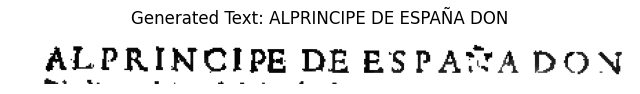

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_1.png
Generated Text: ALPRINCIPE DE ESPAÑA DON


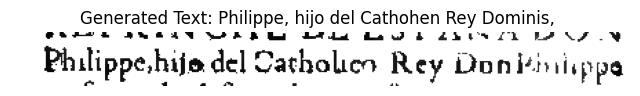

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_2.png
Generated Text: Philippe, hijo del Cathohen Rey Dominis, 


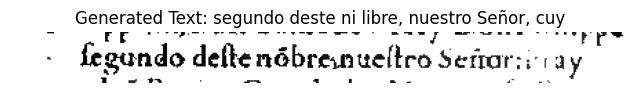

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_3.png
Generated Text: segundo deste ni libre, nuestro Señor, cuy


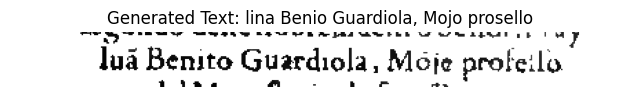

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_4.png
Generated Text: lina Benio Guardiola, Mojo prosello


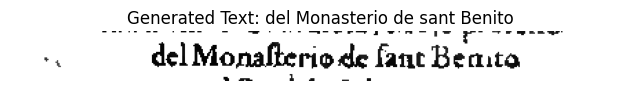

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_5.png
Generated Text: del Monasterio de sant Benito


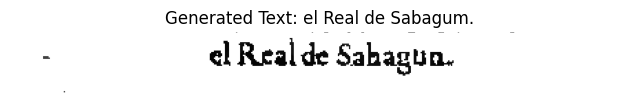

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_6_1.png
Generated Text: el Real de Sabagum.


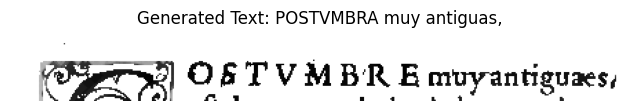

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_7.png
Generated Text: POSTVMBRA muy antiguas,


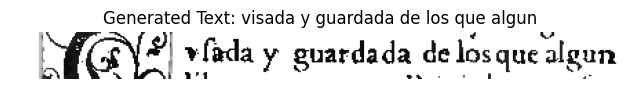

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_8.png
Generated Text: visada y guardada de los que algun


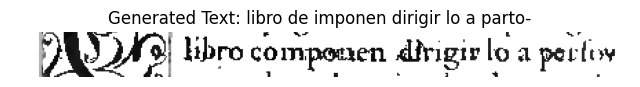

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_9.png
Generated Text: libro de imponen dirigir lo a parto-


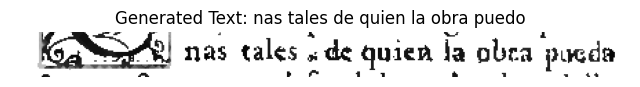

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_10.png
Generated Text: nas tales de quien la obra puedo


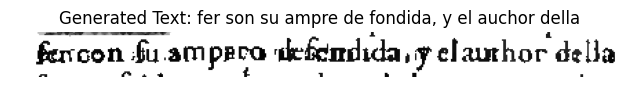

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_11.png
Generated Text: fer son su ampre de fondida, y el auchor della


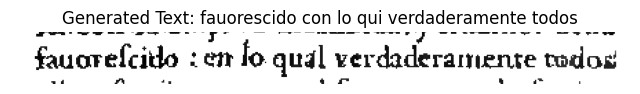

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_12.png
Generated Text: fauorescido con lo qui verdaderamente todos


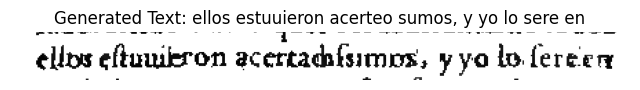

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_13.png
Generated Text: ellos estuuieron acerteo sumos, y yo lo sere en


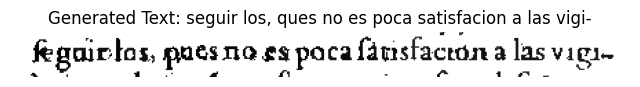

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_14.png
Generated Text: seguir los, ques no es poca satisfacion a las vigi-


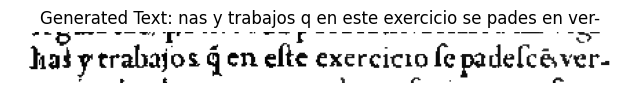

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_15.png
Generated Text: nas y trabajos q en este exercicio se pades en ver-


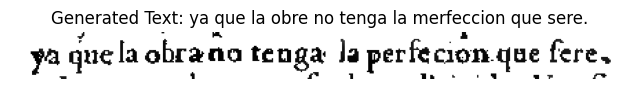

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_16.png
Generated Text: ya que la obre no tenga la merfeccion que sere.


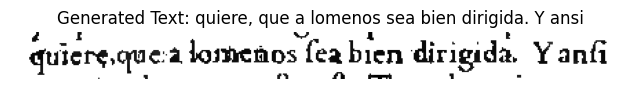

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_17.png
Generated Text: quiere, que a lomenos sea bien dirigida. Y ansi


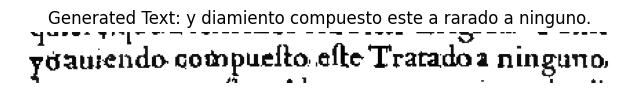

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_18.png
Generated Text: y diamiento compuesto este a rarado a ninguno.


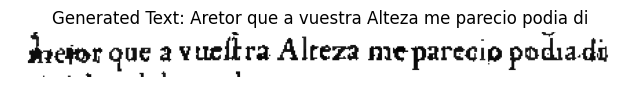

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_19.png
Generated Text: Aretor que a vuestra Alteza me parecio podia di


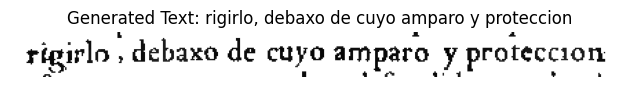

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_20.png
Generated Text: rigirlo, debaxo de cuyo amparo y proteccion


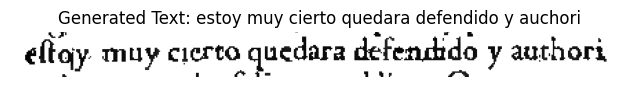

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_21.png
Generated Text: estoy muy cierto quedara defendido y auchori


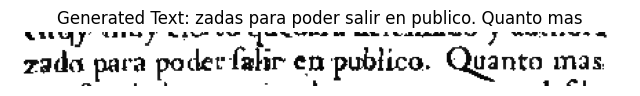

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_22.png
Generated Text: zadas para poder salir en publico. Quanto mas


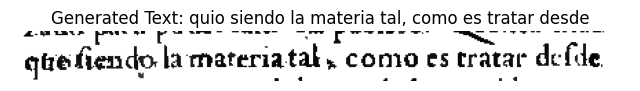

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_23.png
Generated Text: quio siendo la materia tal, como es tratar desde


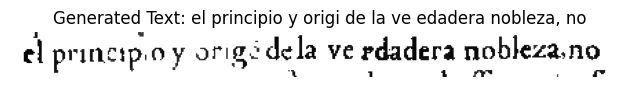

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_24.png
Generated Text: el principio y origi de la ve edadera nobleza, no


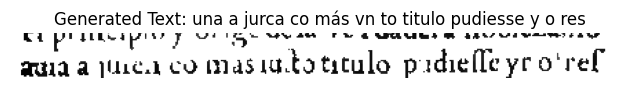

Image Path: ./test/Guardiola_test\Guardiola - Tratado nobleza_page_24.png_line_25.png
Generated Text: una a jurca co más vn to titulo pudiesse y o res
1 : ALPRINCIPE DE ESPAÑA DON
2 : Philippe, hijo del Cathohen Rey Dominis, 
3 : segundo deste ni libre, nuestro Señor, cuy
4 : lina Benio Guardiola, Mojo prosello
5 : del Monasterio de sant Benito
6 : el Real de Sabagum.
7 : POSTVMBRA muy antiguas,
8 : visada y guardada de los que algun
9 : libro de imponen dirigir lo a parto-
10 : nas tales de quien la obra puedo
11 : fer son su ampre de fondida, y el auchor della
12 : fauorescido con lo qui verdaderamente todos
13 : ellos estuuieron acerteo sumos, y yo lo sere en
14 : seguir los, ques no es poca satisfacion a las vigi-
15 : nas y trabajos q en este exercicio se pades en ver-
16 : ya que la obre no tenga la merfeccion que sere.
17 : quiere, que a lomenos sea bien dirigida. Y ansi
18 : y diamiento compuesto este a rarado a ninguno.
19 : Aretor que a vuestra Alteza me parecio podia di
20 :

In [12]:
# Load images from the specified directory
image_directory = "./test/Guardiola_test"
target_size = (256, 64)
img_path = '/content/Guardiola - Tratado nobleza_page_24.png'
line_images, image_paths = load_images_from_directory(img_path, image_directory, target_size)

# Generate texts for the loaded images
generated_texts = generate_texts_from_images(line_images, target_size=target_size, batch_size=2)

gen_text = []
# Display the images with their generated texts
for img_path, img, text in zip(image_paths, line_images, generated_texts):
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"Generated Text: {text}")
    plt.axis('off')
    plt.show()
    gen_text.append(text)
    print(f"Image Path: {img_path}\nGenerated Text: {text}\n{'='*50}")

for i, pred in enumerate(gen_text):
    print(f"{i+1} : {pred}")

In [ ]:
#v2 test

In [21]:
import torch
from torch.utils.data import DataLoader
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import re
import cv2
import string
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# Sanitize the generated text to be used as a filename
def sanitize_filename(text):
    valid_chars = "-_.() %s%s" % (string.ascii_letters, string.digits)
    sanitized = ''.join(c for c in text if c in valid_chars)
    return sanitized.strip()[:] or "empty_text"

def get_segmented_image_paths(input_path, segmented_image_dir):
    """Get all segmented image paths for a given input image."""
    # Get the base name from the input path (without extension)
    base_name = os.path.splitext(os.path.basename(input_path))[0]
    
    # List all files in the directory
    try:
        files = os.listdir(segmented_image_dir)
    except FileNotFoundError:
        print(f"Directory not found: {segmented_image_dir}")
        return []
    
    # Filter files that match either pattern:
    # 1. {base_name}_line_{numbers}.png (compound line numbers)
    # 2. {base_name}.png_line_{numbers}.png (original format)
    segmented_files = []
    pattern1_count = 0  # {base_name}_line_*.png
    pattern2_count = 0  # {base_name}.png_line_*.png
    
    for f in files:
        full_path = os.path.join(segmented_image_dir, f)
        
        # Pattern 1: base_name_line_*.png (for compound line numbers)
        if f.startswith(base_name + "_line_") and f.endswith(".png"):
            segmented_files.append(full_path)
            pattern1_count += 1
        # Pattern 2: base_name.png_line_*.png (original format)
        elif f.startswith(base_name + ".png_line_") and f.endswith(".png"):
            segmented_files.append(full_path)
            pattern2_count += 1
    
    print(f"Found {len(segmented_files)} segmented files for base name: {base_name}")
    print(f"  Pattern 1 ({base_name}_line_*.png): {pattern1_count} files")
    print(f"  Pattern 2 ({base_name}.png_line_*.png): {pattern2_count} files")
    
    if len(segmented_files) == 0:
        print("No matching files found. First few files in directory:")
        for i, f in enumerate(files[:10]):
            if base_name in f:
                print(f"  {f} (contains base name)")
            elif i < 5:
                print(f"  {f}")
    
    return segmented_files

def extract_line_number(file_path):
    """
    Extract line number(s) from the file name and return a tuple for proper sorting.
    Handles cases like:
    - _line_1.png -> (1,)
    - _line_9.png -> (9,)
    - _line_9_1.png -> (9, 1)
    - _line_10.png -> (10,)
    - _line_10_2.png -> (10, 2)
    """
    filename = os.path.basename(file_path)
    
    # Look for the pattern _line_[numbers with underscores].png
    match = re.search(r'_line_([0-9]+(?:_[0-9]+)*)\.png$', filename)
    
    if match:
        line_part = match.group(1)
        # Split by underscore and convert to integers
        try:
            numbers = [int(x) for x in line_part.split('_')]
            return tuple(numbers)
        except ValueError:
            print(f"Warning: Could not parse line numbers from {filename}")
            return (float('inf'),)
    else:
        print(f"Warning: No line number found in {filename}")
        return (float('inf'),)

def sort_segmented_image_paths(image_paths):
    """
    Sort the list of paths based on the extracted line numbers.
    This handles multi-part line numbers properly.
    """
    if not image_paths:
        return []
    
    # Sort using the tuple returned by extract_line_number
    sorted_paths = sorted(image_paths, key=extract_line_number)
    
    # Debug output
    print("\nSorting details:")
    for i, path in enumerate(sorted_paths):
        line_nums = extract_line_number(path)
        filename = os.path.basename(path)
        print(f"  {i+1:2d}: {filename} -> {line_nums}")
    
    return sorted_paths

def load_images_from_directory(img_path, directory_path, target_size):
    """Load and sort images from directory."""
    images = []
    
    # Get sorted image paths
    image_paths = get_segmented_image_paths(img_path, directory_path)
    
    if not image_paths:
        print("No segmented images found!")
        return [], []
    
    image_paths = sort_segmented_image_paths(image_paths)
    
    print(f"\nLoading {len(image_paths)} images...")
    
    for i, filename in enumerate(image_paths):
        try:
            image = Image.open(filename).convert("RGB")  # Ensure 3 channels
            # image = image.resize(target_size, Image.BILINEAR)
            image = np.array(image, dtype=np.uint8)  # Ensure dtype uint8
            images.append(image)
        except Exception as e:
            print(f"Error loading image {filename}: {e}")
    
    print(f"Successfully loaded {len(images)} images")
    return images, image_paths

# Generate text from images
def generate_texts_from_images(line_images, target_size=(256, 64), batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_path = "./finetuned_transformer_model_v4"
    processor_path = "./finetuned_transformer_model_v4"
    processor = TrOCRProcessor.from_pretrained(processor_path)
    model = VisionEncoderDecoderModel.from_pretrained(model_path)
    dataset = LineDataset(processor, model, line_images, [""] * len(line_images), target_size, apply_augmentation=False)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    model = dataset.model.to(device)
    model.eval()
    generated_texts = []
    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch["pixel_values"].to(device)
            generated_ids = model.generate(pixel_values)
            generated_texts_batch = processor.batch_decode(generated_ids, skip_special_tokens=True)
            generated_texts.extend(generated_texts_batch)
    return generated_texts


Found 44 segmented files for base name: VE.210.60 – 1622_page_1
  Pattern 1 (VE.210.60 – 1622_page_1_line_*.png): 4 files
  Pattern 2 (VE.210.60 – 1622_page_1.png_line_*.png): 40 files

Sorting details:
   1: VE.210.60 – 1622_page_1.png_line_1.png -> (1,)
   2: VE.210.60 – 1622_page_1_line_1_1.png -> (1, 1)
   3: VE.210.60 – 1622_page_1.png_line_3.png -> (3,)
   4: VE.210.60 – 1622_page_1_line_3_1.png -> (3, 1)
   5: VE.210.60 – 1622_page_1.png_line_5.png -> (5,)
   6: VE.210.60 – 1622_page_1.png_line_6.png -> (6,)
   7: VE.210.60 – 1622_page_1.png_line_7.png -> (7,)
   8: VE.210.60 – 1622_page_1.png_line_8.png -> (8,)
   9: VE.210.60 – 1622_page_1.png_line_9.png -> (9,)
  10: VE.210.60 – 1622_page_1.png_line_10.png -> (10,)
  11: VE.210.60 – 1622_page_1.png_line_11.png -> (11,)
  12: VE.210.60 – 1622_page_1.png_line_12.png -> (12,)
  13: VE.210.60 – 1622_page_1.png_line_13.png -> (13,)
  14: VE.210.60 – 1622_page_1.png_line_14.png -> (14,)
  15: VE.210.60 – 1622_page_1.png_line_15.png

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 1024,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 16,
  "num_channels": 3,
  "num_hidden_layers": 24,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 1024,
  "qkv_bias": false,
  "torch_dtype": "float32",
  "transformers_version": "4.49.0"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "d_model": 1024,
  "decoder_attention_head

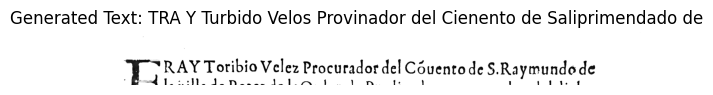

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_1.png
Generated Text: TRA Y Turbido Velos Provinador del Cienento de Saliprimendado de
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\TRA Y Turbido Velos Provinador del Cienento de Saliprimendado de.png


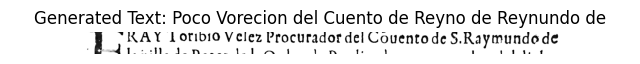

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1_line_1_1.png
Generated Text: Poco Vorecion del Cuento de Reyno de Reynundo de
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\Poco Vorecion del Cuento de Reyno de Reynundo de.png


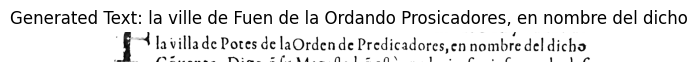

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_3.png
Generated Text: la ville de Fuen de la Ordando Prosicadores, en nombre del dicho
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\la ville de Fuen de la Ordando Prosicadores en nombre del dicho.png


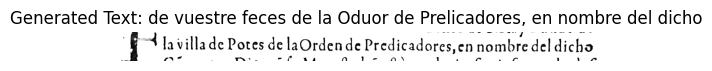

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1_line_3_1.png
Generated Text: de vuestre feces de la Oduor de Prelicadores, en nombre del dicho
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\de vuestre feces de la Oduor de Prelicadores en nombre del dicho.png


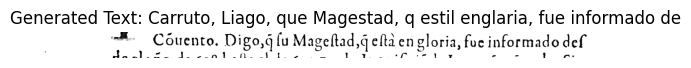

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_5.png
Generated Text: Carruto, Liago, que Magestad, q estil englaria, fue informado de
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\Carruto Liago que Magestad q estil englaria fue informado de.png


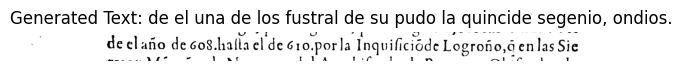

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_6.png
Generated Text: de el una de los fustral de su pudo la quincide segenio, ondios.
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\de el una de los fustral de su pudo la quincide segenio ondios..png


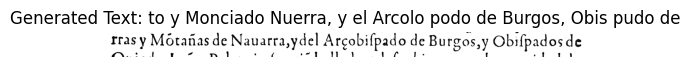

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_7.png
Generated Text: to y Monciado Nuerra, y el Arcolo podo de Burgos, Obis pudo de
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\to y Monciado Nuerra y el Arcolo podo de Burgos Obis pudo de.png


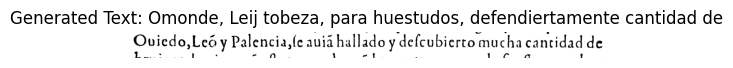

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_8.png
Generated Text: Omonde, Leij tobeza, para huestudos, defendiertamente cantidad de
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\Omonde Leij tobeza para huestudos defendiertamente cantidad de.png


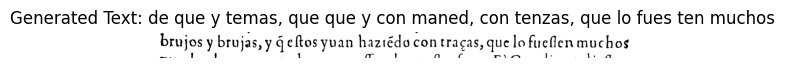

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_9.png
Generated Text: de que y temas, que que y con maned, con tenzas, que lo fues ten muchos
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\de que y temas que que y con maned con tenzas que lo fues ten muchos.png


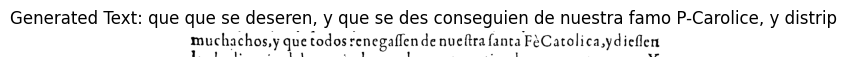

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_10.png
Generated Text: que que se deseren, y que se des conseguien de nuestra famo P-Carolice, y distrip
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\que que se deseren y que se des conseguien de nuestra famo P-Carolice y distrip.png


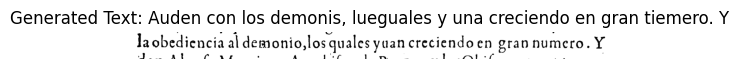

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_11.png
Generated Text: Auden con los demonis, lueguales y una creciendo en gran tiemero. Y
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\Auden con los demonis lueguales y una creciendo en gran tiemero. Y.png


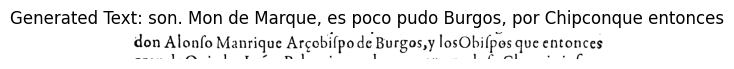

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_12.png
Generated Text: son. Mon de Marque, es poco pudo Burgos, por Chipconque entonces
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\son. Mon de Marque es poco pudo Burgos por Chipconque entonces.png


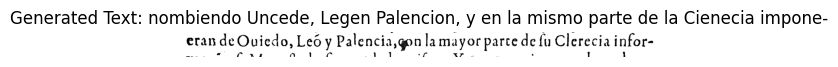

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_13.png
Generated Text: nombiendo Uncede, Legen Palencion, y en la mismo parte de la Cienecia impone-
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\nombiendo Uncede Legen Palencion y en la mismo parte de la Cienecia impone-.png


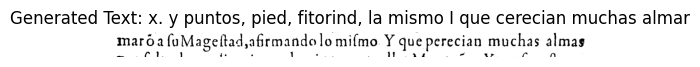

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_14.png
Generated Text: x. y puntos, pied, fitorind, la mismo I que cerecian muchas almar
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\x. y puntos pied fitorind la mismo I que cerecian muchas almar.png


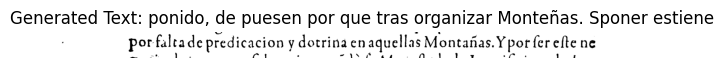

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_15.png
Generated Text: ponido, de puesen por que tras organizar Monteñas. Sponer estiene
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\ponido de puesen por que tras organizar Monteas. Sponer estiene.png


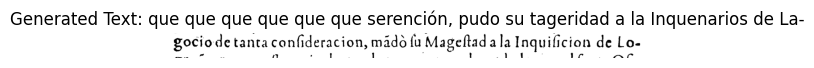

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_16.png
Generated Text: que que que que que que serención, pudo su tageridad a la Inquenarios de La-
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\que que que que que que serencin pudo su tageridad a la Inquenarios de La-.png


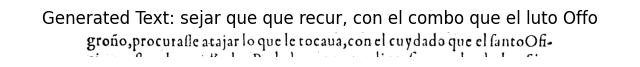

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_17.png
Generated Text: sejar que que recur, con el combo que el luto Offo
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\sejar que que recur con el combo que el luto Offo.png


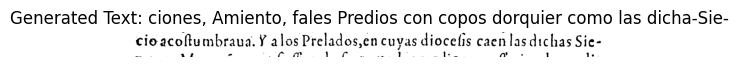

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_18.png
Generated Text: ciones, Amiento, fales Predios con copos dorquier como las dicha-Sie-
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\ciones Amiento fales Predios con copos dorquier como las dicha-Sie-.png


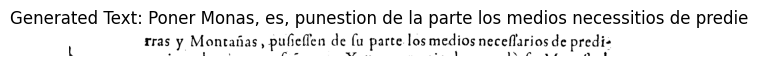

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_19.png
Generated Text: Poner Monas, es, punestion de la parte los medios necessitios de predie
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\Poner Monas es punestion de la parte los medios necessitios de predie.png


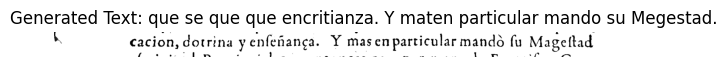

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_20.png
Generated Text: que se que que encritianza. Y maten particular mando su Megestad.
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\que se que que encritianza. Y maten particular mando su Megestad..png


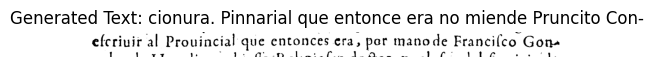

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_21.png
Generated Text: cionura. Pinnarial que entonce era no miende Pruncito Con-
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\cionura. Pinnarial que entonce era no miende Pruncito Con-.png


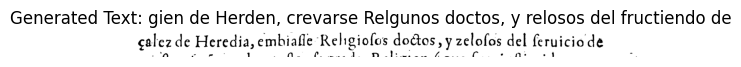

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_22.png
Generated Text: gien de Herden, crevarse Relgunos doctos, y relosos del fructiendo de
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\gien de Herden crevarse Relgunos doctos y relosos del fructiendo de.png


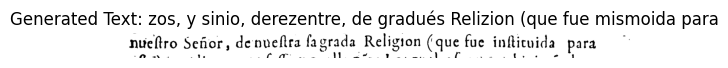

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_23.png
Generated Text: zos, y sinio, derezentre, de gradués Relizion (que fue mismoida para
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\zos y sinio derezentre de gradus Relizion (que fue mismoida para.png


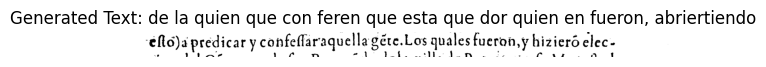

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_24.png
Generated Text: de la quien que con feren que esta que dor quien en fueron, abriertiendo
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\de la quien que con feren que esta que dor quien en fueron abriertiendo.png


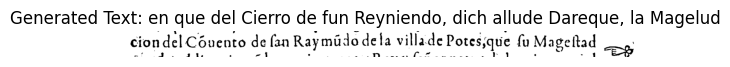

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_25.png
Generated Text: en que del Cierro de fun Reyniendo, dich allude Dareque, la Magelud
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\en que del Cierro de fun Reyniendo dich allude Dareque la Magelud.png


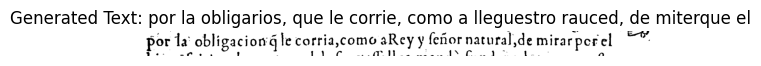

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_26.png
Generated Text: por la obligarios, que le corrie, como a lleguestro rauced, de miterque el
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\por la obligarios que le corrie como a lleguestro rauced de miterque el.png


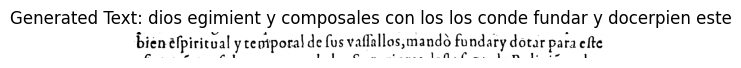

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_27.png
Generated Text: dios egimient y composales con los los conde fundar y docerpien este
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\dios egimient y composales con los los conde fundar y docerpien este.png


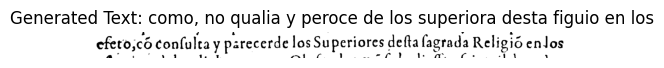

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_28.png
Generated Text: como, no qualia y peroce de los superiora desta figuio en los
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\como no qualia y peroce de los superiora desta figuio en los.png


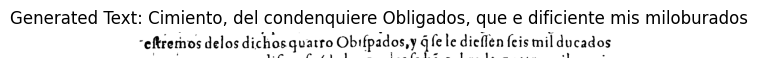

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_29.png
Generated Text: Cimiento, del condenquiere Obligados, que e dificiente mis miloburados
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\Cimiento del condenquiere Obligados que e dificiente mis miloburados.png


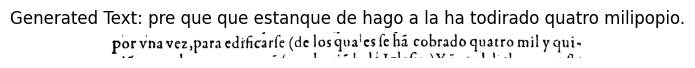

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_30.png
Generated Text: pre que que estanque de hago a la ha todirado quatro milipopio.
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\pre que que estanque de hago a la ha todirado quatro milipopio..png


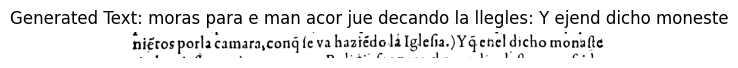

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_31.png
Generated Text: moras para e man acor jue decando la llegles: Y ejend dicho moneste
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\moras para e man acor jue decando la llegles Y ejend dicho moneste.png


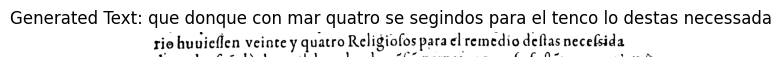

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_32.png
Generated Text: que donque con mar quatro se segindos para el tenco lo destas necessada
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\que donque con mar quatro se segindos para el tenco lo destas necessada.png


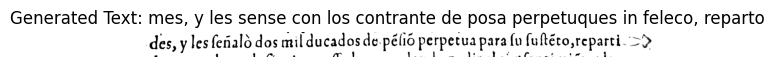

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_33.png
Generated Text: mes, y les sense con los contrante de posa perpetuques in feleco, reparto
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\mes y les sense con los contrante de posa perpetuques in feleco reparto.png


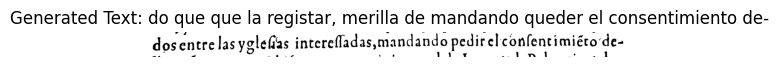

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_34.png
Generated Text: do que que la registar, merilla de mandando queder el consentimiento de-
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\do que que la registar merilla de mandando queder el consentimiento de-.png


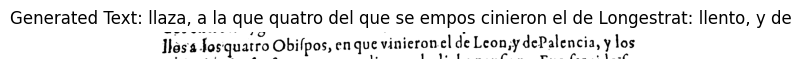

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_35.png
Generated Text: llaza, a la que quatro del que se empos cinieron el de Longestrat: llento, y de
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\llaza a la que quatro del que se empos cinieron el de Longestrat llento y de.png


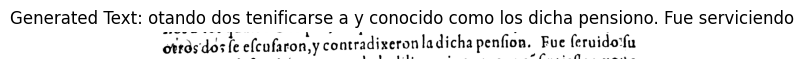

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_36.png
Generated Text: otando dos tenificarse a y conocido como los dicha pensiono. Fue serviciendo
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\otando dos tenificarse a y conocido como los dicha pensiono. Fue serviciendo.png


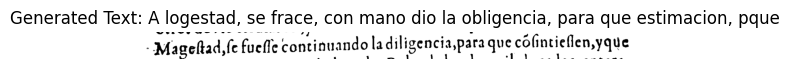

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_37.png
Generated Text: A logestad, se frace, con mano dio la obligencia, para que estimacion, pque
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\A logestad se frace con mano dio la obligencia para que estimacion pque.png


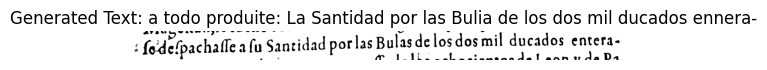

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_38.png
Generated Text: a todo produite: La Santidad por las Bulia de los dos mil ducados ennera-
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\a todo produite La Santidad por las Bulia de los dos mil ducados ennera-.png


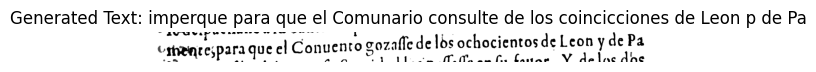

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_39.png
Generated Text: imperque para que el Comunario consulte de los coincicciones de Leon p de Pa
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\imperque para que el Comunario consulte de los coincicciones de Leon p de Pa.png


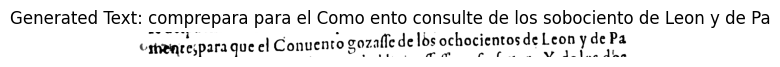

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1_line_39_1.png
Generated Text: comprepara para el Como ento consulte de los sobociento de Leon y de Pa
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\comprepara para el Como ento consulte de los sobociento de Leon y de Pa.png


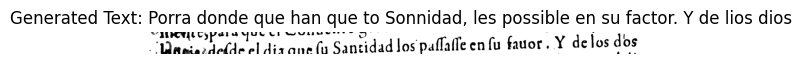

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_41.png
Generated Text: Porra donde que han que to Sonnidad, les possible en su factor. Y de lios dios
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\Porra donde que han que to Sonnidad les possible en su factor. Y de lios dios.png


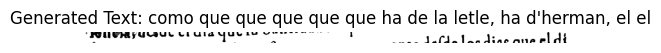

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_42.png
Generated Text: como que que que que que ha de la letle, ha d'herman, el el
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\como que que que que que ha de la letle ha dherman el el.png


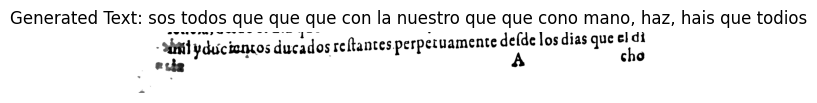

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1.png_line_43.png
Generated Text: sos todos que que que con la nuestro que que cono mano, haz, hais que todios
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\sos todos que que que con la nuestro que que cono mano haz hais que todios.png


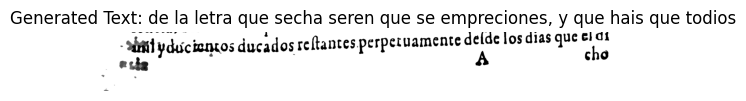

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/VE.210.60 – 1622\VE.210.60 – 1622_page_1_line_43_1.png
Generated Text: de la letra que secha seren que se empreciones, y que hais que todios
Saved As: ./transcribed_images_folder_train/VE.210.60 – 1622-1\de la letra que secha seren que se empreciones y que hais que todios.png
1 : TRA Y Turbido Velos Provinador del Cienento de Saliprimendado de
2 : Poco Vorecion del Cuento de Reyno de Reynundo de
3 : la ville de Fuen de la Ordando Prosicadores, en nombre del dicho
4 : de vuestre feces de la Oduor de Prelicadores, en nombre del dicho
5 : Carruto, Liago, que Magestad, q estil englaria, fue informado de
6 : de el una de los fustral de su pudo la quincide segenio, ondios.
7 : to y Monciado Nuerra, y el Arcolo podo de Burgos, Obis pudo de
8 : Omonde, Leij tobeza, para huestudos, defendiertamente cantidad de
9 : de que y temas, que que y con maned, con tenzas, que lo fues ten muchos
10 : que que se deseren, y que se des c

In [48]:
# --- Main Execution ---
num = 1

book = 'VE.210.60 – 1622'
image_directory = f"./A/New Line Segmented Images/Dataset A - Raw Line Segments/{book}"
img_path = f'/content/{book}_page_{num}.png'
target_size = (256, 64)

# Load images
line_images, image_paths = load_images_from_directory(img_path, image_directory, target_size)

# Generate text
generated_texts = generate_texts_from_images(line_images, target_size=target_size, batch_size=2)

# Create output folder
transcribed_dir = f"./transcribed_images_folder_train/{book}-{num}"
os.makedirs(transcribed_dir, exist_ok=True)

gen_text = []

# Display, print, and save the image using the generated text as filename
for img_path, img, text in zip(image_paths, line_images, generated_texts):
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"Generated Text: {text}")
    plt.axis('off')
    plt.show()

    sanitized_name = sanitize_filename(text)
    save_path = os.path.join(transcribed_dir, f"{sanitized_name}.png")

    Image.fromarray(img).save(save_path)

    gen_text.append(text)
    print(f"Image Path: {img_path}\nGenerated Text: {text}\nSaved As: {save_path}\n{'='*50}")

# Print all generated texts
for i, pred in enumerate(gen_text):
    print(f"{i+1} : {pred}")


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 1024,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 16,
  "num_channels": 3,
  "num_hidden_layers": 24,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 1024,
  "qkv_bias": false,
  "torch_dtype": "float32",
  "transformers_version": "4.49.0"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "d_model": 1024,
  "decoder_attention_head

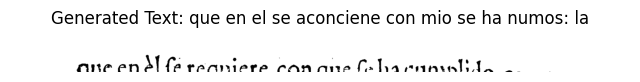

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_1.png
Generated Text: que en el se aconciene con mio se ha numos: la


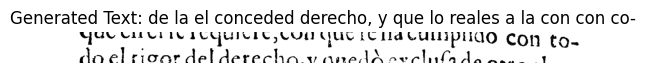

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_2.png
Generated Text: de la el conceded derecho, y que lo reales a la con con co-


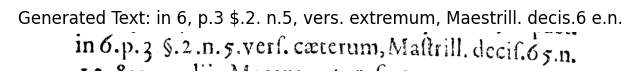

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_9.png
Generated Text: in 6, p.3 $.2. n.5, vers. extremum, Maestrill. decis.6 e.n.


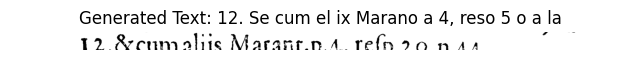

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_10.png
Generated Text: 12. Se cum el ix Marano a 4, reso 5 o a la


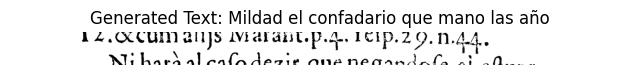

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_11.png
Generated Text: Mildad el confadario que mano las año


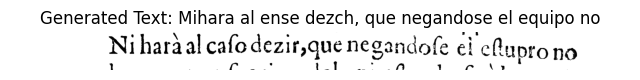

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_12.png
Generated Text: Mihara al ense dezch, que negandose el equipo no


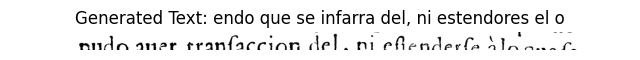

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_13.png
Generated Text: endo que se infarra del, ni estendores el o


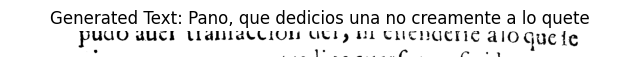

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_14.png
Generated Text: Pano, que dedicios una no creamente a lo quete


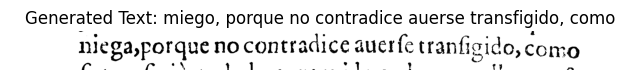

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_15.png
Generated Text: miego, porque no contradice auerse transfigido, como


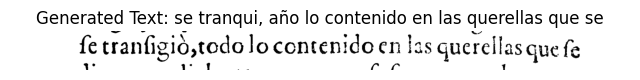

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_16.png
Generated Text: se tranqui, año lo contenido en las querellas que se


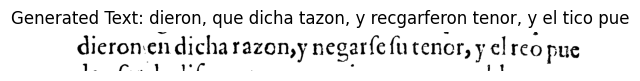

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_17.png
Generated Text: dieron, que dicha tazon, y recgarferon tenor, y el tico pue


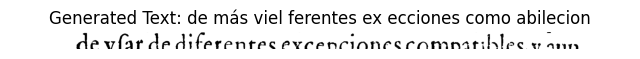

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_18.png
Generated Text: de más viel ferentes ex ecciones como abilecion


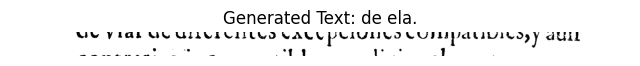

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_19.png
Generated Text: de ela.


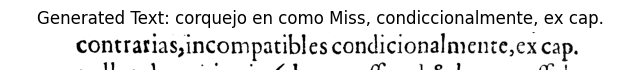

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_20.png
Generated Text: corquejo en como Miss, condiccionalmente, ex cap.


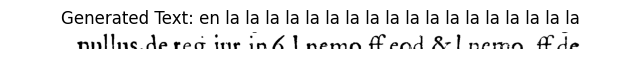

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_21.png
Generated Text: en la la la la la la la la la la la la la la la la la la


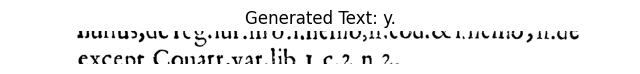

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_22.png
Generated Text: y.


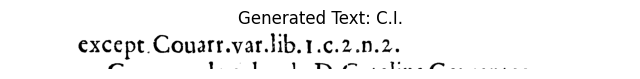

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_23.png
Generated Text: C.I.


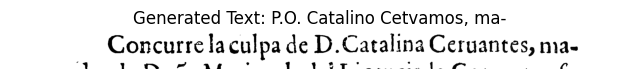

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_24.png
Generated Text: P.O. Catalino Cetvamos, ma-


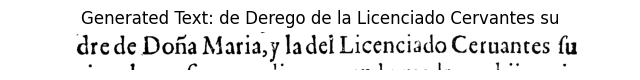

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_25.png
Generated Text: de Derego de la Licenciado Cervantes su


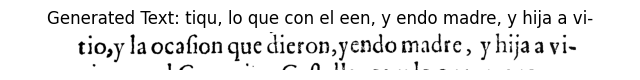

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_26.png
Generated Text: tiqu, lo que con el een, y endo madre, y hija a vi-


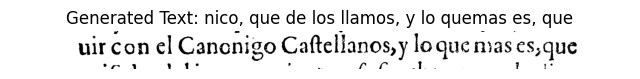

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_27.png
Generated Text: nico, que de los llamos, y lo quemas es, que


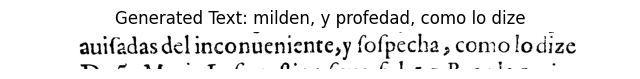

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_28.png
Generated Text: milden, y profedad, como lo dize


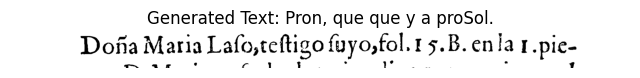

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_29.png
Generated Text: Pron, que que y a proSol.


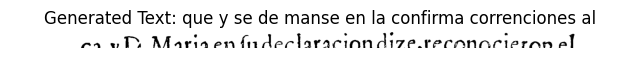

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_30.png
Generated Text: que y se de manse en la confirma correnciones al


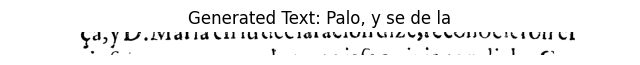

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_31.png
Generated Text: Palo, y se de la


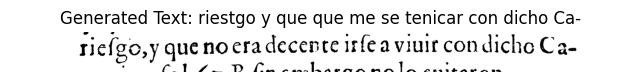

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_32.png
Generated Text: riestgo y que que me se tenicar con dicho Ca-


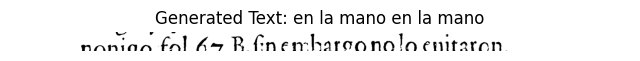

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_33.png
Generated Text: en la mano en la mano


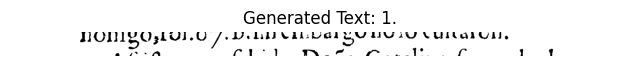

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_34.png
Generated Text: 1.


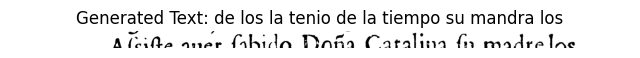

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_35.png
Generated Text: de los la tenio de la tiempo su mandra los


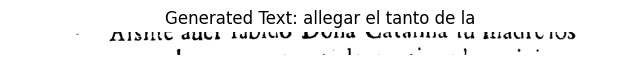

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_36.png
Generated Text: allegar el tanto de la


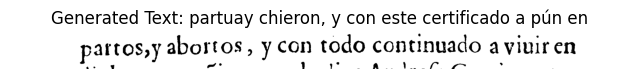

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_37.png
Generated Text: partuay chieron, y con este certificado a pún en


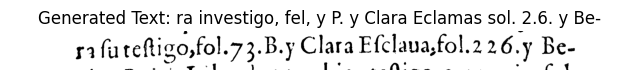

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_40.png
Generated Text: ra investigo, fel, y P. y Clara Eclamas sol. 2.6. y Be-


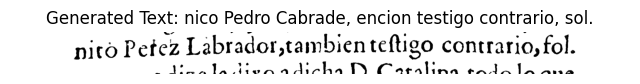

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_41.png
Generated Text: nico Pedro Cabrade, encion testigo contrario, sol.


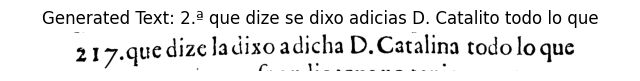

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_42.png
Generated Text: 2.ª que dize se dixo adicias D. Catalito todo lo que


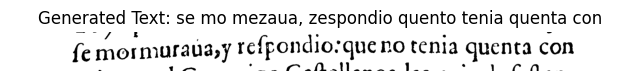

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_43.png
Generated Text: se mo mezaua, zespondio quento tenia quenta con


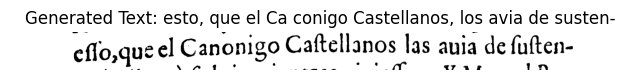

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_44.png
Generated Text: esto, que el Ca conigo Castellanos, los avia de susten-


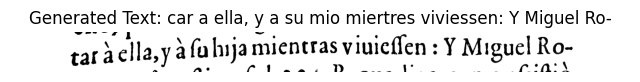

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_45.png
Generated Text: car a ella, y a su mio miertres viviessen: Y Miguel Ro-


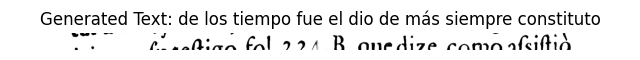

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_46.png
Generated Text: de los tiempo fue el dio de más siempre constituto


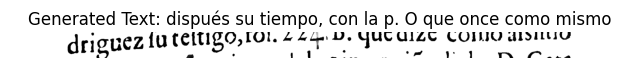

Image Path: ./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644\PORCONES.82.4 – 1644_page_20.png_line_47.png
Generated Text: dispués su tiempo, con la p. O que once como mismo
1 : que en el se aconciene con mio se ha numos: la
2 : de la el conceded derecho, y que lo reales a la con con co-
3 : in 6, p.3 $.2. n.5, vers. extremum, Maestrill. decis.6 e.n.
4 : 12. Se cum el ix Marano a 4, reso 5 o a la
5 : Mildad el confadario que mano las año
6 : Mihara al ense dezch, que negandose el equipo no
7 : endo que se infarra del, ni estendores el o
8 : Pano, que dedicios una no creamente a lo quete
9 : miego, porque no contradice auerse transfigido, como
10 : se tranqui, año lo contenido en las querellas que se
11 : dieron, que dicha tazon, y recgarferon tenor, y el tico pue
12 : de más viel ferentes ex ecciones como abilecion
13 : de ela.
14 : corquejo en como Miss, condiccionalmente, ex cap.
15 : en la la la la la la la la la la la la la la la la la la
16 : y.
17 :

In [12]:
# Load images from the specified directory
image_directory = "./A/New Line Segmented Images/Dataset A - Raw Line Segments/PORCONES.82.4 – 1644"
target_size = (256, 64)
img_path = '/content/PORCONES.82.4 – 1644_page_20.png'
line_images, image_paths = load_images_from_directory(img_path, image_directory, target_size)

# Generate texts for the loaded images
generated_texts = generate_texts_from_images(line_images, target_size=target_size, batch_size=2)

gen_text = []
# Display the images with their generated texts
for img_path, img, text in zip(image_paths, line_images, generated_texts):
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"Generated Text: {text}")
    plt.axis('off')
    plt.show()
    gen_text.append(text)
    print(f"Image Path: {img_path}\nGenerated Text: {text}\n{'='*50}")

for i, pred in enumerate(gen_text):
    print(f"{i+1} : {pred}")